# 13. Portfolio Optimization with Reinforcement Learning

This tutorial provides a step-by-step guide for implementing a Unit Operator with a Portfolio Strategy in the ASSUME framework. By the end of this guide, you will be familiar with the process of creating and integrating a Portfolio within the electricity market simulation environment provided by ASSUME.


**We will cover the following topics:**

1. [Introduction to Unit Operators and Portfolio Strategy](#1.-introduction-to-unit-operators-and-portfolio-strategy)
2. [Setting up the ASSUME framework](#2.-setting-up-assume)
3. [Developing a portfolio RL strategy](#3.-portfolio-reinforcement-learning-strategy)
4. [Running the simulations](#4.-running-the-simulations)
5. [Comparing scenarios in ASSUME](#5.-comparing-and-evaluating-scenarios)

## 1. Introduction to Unit Operators and Portfolio Strategy

The ASSUME framework is a versatile tool for simulating electricity markets, allowing researchers and industry professionals to analyze market dynamics and strategies.

A **UnitsOperator** in ASSUME refers to a market role that submits buy or sell bids in the market for multiple units in its portfolio, according to the bidding strategy of each unit. Unit operators can themselves have a portfolio strategy, that is a **UnitOperatorStrategy**, which aims at optimizing the joint market returns from the bids of all units of the operator. 

In this tutorial, we will create a portfolio strategy for a unit operator with multiple units.

## Why portfolio optimization 

#TODO Explanation

#TODO Picture


In [240]:
# this cell is used to display the image in the notebook when using colab
# or running the notebook locally

import os
import matplotlib.pyplot as plt
from IPython.display import Image, display, SVG

image_path = "assume-repo/docs/source/img/new_picture.svg"
alt_image_path = "../../docs/source/img/new_picture.svg"

# Try to display SVG using different methods
if os.path.exists(image_path):
    display(SVG(image_path))
elif os.path.exists(alt_image_path):
    display(SVG(alt_image_path))
else:
    print("Image file not found. Please check the path.")


Image file not found. Please check the path.


#TODO: rewrite picture description 

## 2. Setting Up ASSUME

Before we create our custom unit, let's set up the ASSUME framework. We'll install the ASSUME core package and clone the repository containing predefined scenarios.

**You don't need to execute the following code cells if you already have the ASSUME framework installed and/or the repository cloned.**

In [241]:
import importlib.util

# Check if 'google.colab' is available
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    !pip install assume-framework

In [242]:
if IN_COLAB:
    !git clone --depth=1 https://github.com/assume-framework/assume.git assume-repo

Note that Google Colab does not support Docker functionalities, so features dependent on Docker will not be available here.

**Select input files path**

We also need to differentiate between the input file paths when using this tutorial in Google Colab and a local environment. The code snippets will include both options for your convenience.

In [243]:
colab_inputs_path = "assume-repo/examples/inputs"
local_inputs_path = "../inputs"

inputs_path = colab_inputs_path if IN_COLAB else local_inputs_path

## 3. Portfolio Reinforcement Learning Strategy

Now, we'll define a model-free portfolio strategy for a Units Operator. Portfolio strategies optimize the entire portfolio of the operator (i.e., its set of units). 

**Key features of the RL-Portfolio Strategy**
1. **Overrides unit bidding strategies**: the portfolio strategies of an operator is called before the bidding strategies of individual units and can override them.
2. **Transforms a portfolio strategy into unit bids**: The portfolio-level strategy is translated into bids that are assigned to the units in the portfolio. This ensures that the market clearing can be used to determine the dispatch of the units. 
3. **Calculates operator reward**: Rewards are computed at a portfolio-level.

### Calculating bids

The strategy submits a set of N+1 prices for its entire available capacity, N prices for its flexible capacity and 1 for its inflexible capacity. The strategy utilizes a set of global and individual observations to generate actions, which are then transformed into unit-specific bids. 

The RL-algorithm learns during training to perform actions based on a set of observation, in order to optimize the reward of those actions.

Observations include the following components:

- *Forecasted Residual Load* over the foresight period, scaled by the maximum
    demand.
- *Forecasted Price* over the foresight period, scaled by the maximum bid price.
- *Total Inflexible Capacity* of the portfolio, scaled by its total installed capacity.
- *Total Flexible Capacity* of the portfolio, scaled by its total installed capacity.
- *Marginal cost quantiles* for the flexible capacity

Actions are output of the RL-algorithm and are learnt during training 
 1 price for inflexible generation and act_dim-1 prices for flexible generation. Actions are rescaled 
from a range of [-1, 1] to real bid prices in the `calculate_bids` method, then translated into unit-specific bids.


### Calculating rewards

Rewards are based on profit from transactions, minus operational costs. Key components include:

- **Profit**: Determined from the income generated by accepted bids, calculated as the product of
    accepted price, volume, and duration.
- **Operational Costs**: Includes marginal costs and start-up costs when a unit transitions between
    on and off states.
- **Scaling**: A scaling factor to normalize the reward (depends on maximum bid price and total installed capacity).

## 4. Running the simulations

Text(0.5, 1.0, 'Residual load and marginal unit cost')

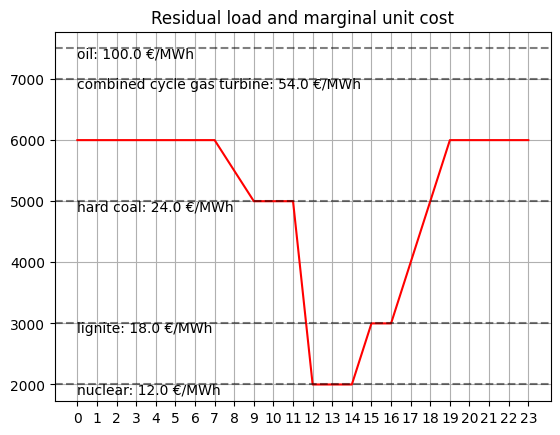

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

GENERATION_MIX = {
                'solar': 10000.0,
                'lignite': 1000.0,
                'hard coal': 2000.0,
                'combined cycle gas turbine': 2000.0,
                'nuclear': 2000.0,
                'oil': 500.0}

MARGINAL_COSTS = {
                'nuclear': 12.0,
                'lignite': 18.0,
                'hard coal': 24.0,
                'combined cycle gas turbine': 54.0,
                'oil': 100.0}
demand = 6000
availability = np.array([0,0,0,0,0,0,0,0,0.05,0.1,0.1,0.1,0.4,0.4,0.4,0.3,0.3,0.2,0.1,0,0,0,0,0])
fig, ax = plt.subplots()

ax.plot(demand -availability * GENERATION_MIX['solar'], label='Residual demand', color='red')

cumgen = 0
for tech, cost in MARGINAL_COSTS.items():
    cap = GENERATION_MIX[tech]
    mc = cost
    cumgen += cap
    ax.axhline(y=cumgen, color='black', linestyle='--', alpha=0.5)
    ax.annotate(f'{tech}: {mc:.1f} €/MWh', xy=(0, cumgen -150))
_ = ax.set_xticks(range(24))
ax.grid(True)
ax.set_title("Residual load and marginal unit cost")

### **Analytical response**

This scenario a portfolio operator that responds with profit-maximizing bids given perfect foresight.

In [133]:
from assume.strategies.portfolio_strategies import UnitOperatorStrategy
import os
from assume import World
from assume.scenario.loader_csv import load_scenario_folder
from util_funcs.learning import seed_everything
%load_ext autoreload
%autoreload 2



os.makedirs("local_db", exist_ok=True)
inputs_path = "inputs"
base_ex = "base_mc"
mc_uri = f"sqlite:///local_db/{base_ex}.db"
mc_world = World(database_uri=mc_uri, export_csv_path=f"outputs/{base_ex}")
load_scenario_folder(
    mc_world,
    inputs_path=inputs_path,
    scenario=base_ex,
    study_case=False,
)

mc_world.run()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
INFO:assume.world:Connected to the database


base_mc_base 2019-01-02 00:00:00:  96%|█████████▌| 86401/90000 [00:00<00:00, 830915.26it/s]


In [2]:
from util_funcs.bilevel_solution import BilevelSolution
from assume.strategies.portfolio_strategies import UnitOperatorStrategy

class BestResponseStartegy(UnitOperatorStrategy):

    def __init__(self, *args, **kwargs):
        
        self.best_response = kwargs.get("best_response", {})
        self.min_lambda = kwargs.get("min_lambda", 1)
        self.max_lambda = kwargs.get("max_lambda", 3)
        
    def calculate_bids(
        self,
        units_operator,  
        market_config, 
        product_tuples, 
        **kwargs,
    ): 

        start, end, only_hours = product_tuples[0]
        bids = []

        for unit_id, unit in units_operator.units.items():
            res_load = unit.forecaster.residual_load[market_config.market_id][start]
            price = self.best_response[res_load][unit_id]
            if price is None:
                price = unit.calculate_marginal_cost(start, 0) * self.max_lambda
            bids.append( {
                    "start_time": start,
                    "end_time": end,
                    "only_hours":only_hours,
                    "price": price,
                    "volume": unit.max_power,
                    "node": unit.node,
                    "bid_id": unit.id,
                    "unit_id": unit.id,
                })
            
        return bids
    
best_uri = f"sqlite:///local_db/best.db"
best_world = World(database_uri=best_uri, export_csv_path=f"outputs/best")
load_scenario_folder(
    best_world,
    inputs_path=inputs_path,
    scenario=base_ex,
    study_case=False,
)

seed_everything(42)

BilevOpt = BilevelSolution(best_world, operator_id="Operator-RL", market_id="EOM")
response_dict = BilevOpt.find_optimal_response(tie_break_rule=True)
best_world.unit_operators["Operator-RL"].portfolio_strategies["EOM"] = BestResponseStartegy(best_response=response_dict)
best_world.run()

INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: inputs/base_mc
INFO:assume.scenario.loader_csv:Study case: False
INFO:assume.scenario.loader_csv:Simulation ID: base_mc_base
INFO:assume.scenario.loader_csv:unit_operators not found. Returning None
INFO:assume.scenario.loader_csv:storage_units not found. Returning None
INFO:assume.scenario.loader_csv:exchange_units not found. Returning None
INFO:assume.scenario.loader_csv:industrial_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:residential_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:forecasts_df not found. Returning None
INFO:assume.scenario.loader_csv:exchanges_df not found. Returning None
INFO:assume.scenario.loader_csv:buses not found. Returning None
INFO:assume.scenario.loader_csv:lines not found. Returning None
INFO:assume.scenario.loader_csv:Adding markets
INFO:assume.scenario.loader_csv:Read units from dataframe
INFO:assume.scenario.loader_c

  0%|          | 0/6 [00:00<?, ?it/s]

INFO:gurobipy:Set parameter WLSAccessID
INFO:gurobipy:Set parameter WLSSecret
INFO:gurobipy:Set parameter LicenseID to value 2767496
INFO:gurobipy:Academic license 2767496 - for non-commercial use only - registered to c.___@hertie-school.org
INFO:gurobipy:Read LP format model from file C:\Users\CFDB2~1.FUS\AppData\Local\Temp\2\tmpljk9ug01.pyomo.lp
INFO:gurobipy:Reading time = 0.00 seconds
INFO:gurobipy:x1: 23 rows, 30 columns, 51 nonzeros
INFO:gurobipy:Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows Server 2022.0 (20348.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel Xeon Processor (Icelake), instruction set [SSE2|AVX|AVX2|AVX512]
INFO:gurobipy:Thread count: 10 physical cores, 10 logical processors, using up to 10 threads
INFO:gurobipy:
INFO:gurobipy:Academic license 2767496 - for non-commercial use only - registered to c.___@hertie-school.org
INFO:gurobipy:Optimize a model with 23 rows, 30 columns and 51 nonzeros (Max)
INFO:gurobipy:Model fingerprint: 0x257a26b2
IN

 17%|█▋        | 1/6 [00:00<00:01,  4.28it/s]

INFO:gurobipy:Read LP format model from file C:\Users\CFDB2~1.FUS\AppData\Local\Temp\2\tmp8fkk9jxy.pyomo.lp
INFO:gurobipy:Reading time = 0.00 seconds
INFO:gurobipy:x1: 23 rows, 30 columns, 51 nonzeros
INFO:gurobipy:Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows Server 2022.0 (20348.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel Xeon Processor (Icelake), instruction set [SSE2|AVX|AVX2|AVX512]
INFO:gurobipy:Thread count: 10 physical cores, 10 logical processors, using up to 10 threads
INFO:gurobipy:
INFO:gurobipy:Academic license 2767496 - for non-commercial use only - registered to c.___@hertie-school.org
INFO:gurobipy:Optimize a model with 23 rows, 30 columns and 51 nonzeros (Max)
INFO:gurobipy:Model fingerprint: 0xb476eada
INFO:gurobipy:Model has 2 linear objective coefficients
INFO:gurobipy:Model has 2 quadratic objective terms
INFO:gurobipy:Model has 18 quadratic constraints
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [1e+00, 1e+00]
I

...

 67%|██████▋   | 4/6 [00:00<00:00,  5.71it/s]

INFO:gurobipy:Read LP format model from file C:\Users\CFDB2~1.FUS\AppData\Local\Temp\2\tmpvl2usxxm.pyomo.lp
INFO:gurobipy:Reading time = 0.00 seconds
INFO:gurobipy:x1: 23 rows, 30 columns, 51 nonzeros
INFO:gurobipy:Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows Server 2022.0 (20348.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel Xeon Processor (Icelake), instruction set [SSE2|AVX|AVX2|AVX512]
INFO:gurobipy:Thread count: 10 physical cores, 10 logical processors, using up to 10 threads
INFO:gurobipy:
INFO:gurobipy:Academic license 2767496 - for non-commercial use only - registered to c.___@hertie-school.org
INFO:gurobipy:Optimize a model with 23 rows, 30 columns and 51 nonzeros (Max)
INFO:gurobipy:Model fingerprint: 0x207ccbb7
INFO:gurobipy:Model has 2 linear objective coefficients
INFO:gurobipy:Model has 2 quadratic objective terms
INFO:gurobipy:Model has 18 quadratic constraints
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [1e+00, 1e+00]
I

 83%|████████▎ | 5/6 [00:00<00:00,  6.37it/s]

INFO:gurobipy:Read LP format model from file C:\Users\CFDB2~1.FUS\AppData\Local\Temp\2\tmpbb2985oi.pyomo.lp
INFO:gurobipy:Reading time = 0.01 seconds
INFO:gurobipy:x1: 23 rows, 30 columns, 51 nonzeros
INFO:gurobipy:Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows Server 2022.0 (20348.2))
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel Xeon Processor (Icelake), instruction set [SSE2|AVX|AVX2|AVX512]
INFO:gurobipy:Thread count: 10 physical cores, 10 logical processors, using up to 10 threads
INFO:gurobipy:
INFO:gurobipy:Academic license 2767496 - for non-commercial use only - registered to c.___@hertie-school.org
INFO:gurobipy:Optimize a model with 23 rows, 30 columns and 51 nonzeros (Max)
INFO:gurobipy:Model fingerprint: 0x89b9cd1f
INFO:gurobipy:Model has 2 linear objective coefficients
INFO:gurobipy:Model has 2 quadratic objective terms
INFO:gurobipy:Model has 18 quadratic constraints
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [1e+00, 1e+00]
I

base_mc_base 2019-01-02 00:00:00:  96%|█████████▌| 86401/90000 [00:00<00:00, 918215.37it/s]


### **Unit-level strategy and reward**

This scenario includes 3 units which use the `RLStrategy` (introduced in tutorial 4a).

In [17]:
from assume.scenario.loader_csv import load_scenario_folder, run_learning
from assume.world import World
import numpy as np
import os
from util_funcs.learning import seed_everything
%load_ext autoreload
%autoreload 2

os.makedirs("local_db", exist_ok=True)
inputs_path = "inputs"
un_example = "base_un"
un_uri = f"sqlite:///local_db/{un_example}.db"

un_world = World(database_uri=un_uri, export_csv_path=f"outputs/{un_example}")
load_scenario_folder(
    un_world,
    inputs_path=inputs_path,
    scenario=f"{un_example}",
    study_case=False,
)

seed_everything(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: inputs/base_un
INFO:assume.scenario.loader_csv:Study case: False
INFO:assume.scenario.loader_csv:Simulation ID: base_un_base
INFO:assume.scenario.loader_csv:unit_operators not found. Returning None
INFO:assume.scenario.loader_csv:storage_units not found. Returning None
INFO:assume.scenario.loader_csv:exchange_units not found. Returning None
INFO:assume.scenario.loader_csv:industrial_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:residential_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:forecasts_df not found. Returning None
INFO:assume.scenario.loader_csv:exchanges_df not found. Returning None
INFO:assume.scenario.loader_csv:buses not found. Returning None
INFO:assume.scenario.loader_csv:lines not found. Returning None
INFO:assume.scenario.loader_csv:Adding markets

c:\Users\c.fusarbassini\Desktop\assume\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\c.fusarbassini\Desktop\assume\.venv\Lib\site-packages\torch\backends\__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  self.setter(val)


In [23]:
%%time
# Run the training phase

if getattr(un_world.learning_config, "learning_mode", False):
    run_learning(un_world)

# # Execute final evaluation run (no exploration)
un_world.run()


CPU times: total: 0 ns
Wall time: 470 μs


RuntimeError: Container is already ready

### **Portfolio-level strategy and reward** 

In this scenario, the market structure remains equal, but the 5 CCGT units are managed by an RL-operator using the `PortfolioRLStrategy`.

In [62]:
from assume import World
from assume.scenario.loader_csv import load_scenario_folder, run_learning
from util_funcs.learning import seed_everything
%load_ext autoreload
%autoreload 2

import yaml 
import os 

os.makedirs("local_db", exist_ok=True)
inputs_path = "inputs"

op_example = "base_op"
op_uri = f"sqlite:///local_db/{op_example}.db"
export_csv_path = f"outputs/{op_example}"
op_world = World(database_uri=op_uri, export_csv_path=export_csv_path)

load_scenario_folder(
    op_world,
    inputs_path=inputs_path,
    scenario=f"{op_example}",
    study_case=False,
)

seed_everything(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
INFO:assume.world:Connected to the database


In [63]:
%%time
# Run the training phase

if getattr(op_world.learning_config, "learning_mode", False):
    run_learning(op_world)

# # Execute final evaluation run (no exploration)
op_world.run()

INFO:assume.common.utils:Previous strategies at 'inputs/base_op/learned_strategies/base_op_base/last_policies' deleted. Starting fresh training.


Training Episode 1 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 885602.44it/s]
Training Episode 2 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 864089.11it/s]
Training Episode 3 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 843883.02it/s]
Training Episode 4 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 889434.45it/s]
Training Episode 5 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 870015.87it/s]
Training Episode 6 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 869427.25it/s]
Training Episode 7 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 715926.67it/s]
Training Episode 8 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 842274.70it/s]
Training Episode 9 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 837107.16it/s]
Training Episode 10 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 823929.16it/s]

INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 1, metric='avg_reward', value=1.95


Training Episode 26 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 311424.08it/s]
Training Episode 27 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 344627.87it/s]
Training Episode 28 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 284461.32it/s]
Training Episode 29 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 338990.84it/s]
Training Episode 30 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 328996.90it/s]
Evaluation Episode 2 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 759241.54it/s]

INFO:assume.reinforcement_learning.learning_role:Current policy not better than best policy, episode: 2, metric='avg_reward', value=1.54


...

INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 20, metric='avg_reward', value=3.20


Training Episode 121 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 344987.44it/s]
Training Episode 122 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 330441.66it/s]
Training Episode 123 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 336215.03it/s]
Training Episode 124 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 306328.70it/s]
Training Episode 125 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 300658.21it/s]
Evaluation Episode 21 2019-01-02 00:00:00:  96%|█████████▌| 86401.0/90000 [00:00<00:00, 733374.87it/s]

INFO:assume.reinforcement_learning.learning_role:Current policy not better than best policy, episode: 21, metric='avg_reward', value=3.19
INFO:assume.reinforcement_learning.learning_role:Stopping training as no improvement above 5.0% in last 10 evaluations for avg_reward
INFO:assume.reinforcement_learning.learning_role:Learning rate schedule (None) or action noise schedule (linear) were scheduled to decay, further learning improvement can be possible. End value of schedule may not have been reached.



base_op_base 2019-01-02 00:00:00:  96%|█████████▌| 86401/90000 [00:00<00:00, 550724.38it/s]


CPU times: total: 7min 21s
Wall time: 58.9 s


## 5. Comparing and evaluating scenarios

After running both simulations, we can now compare them through loading the SQL databases and plotting the results.

We cannot directly compare the rewards of the two scenarios as `RLStrategy`(used in multi-agent simulation 02b) and `PortfolioRLStrategy` (used in portfolio-agent simulation 02f) use different formulas to compute rewards. However, the total profits in the scenarios are equal to revenues - operational costs (marginal and start-up costs) for both strategies. Since in both cases, the same units are implementing an RL strategies, their installed capacity and marginal costs are comparable. 

**Plotting the average profits by episode**

In [134]:
from util_funcs.db_plot import *
from util_funcs.db_read import * 

un_example, op_example = "base_un", "base_op"
# Load query results
profit_dfs =  {
      "unit": read_rl_params(un_example),
      "operator": read_rl_params(op_example),
      }


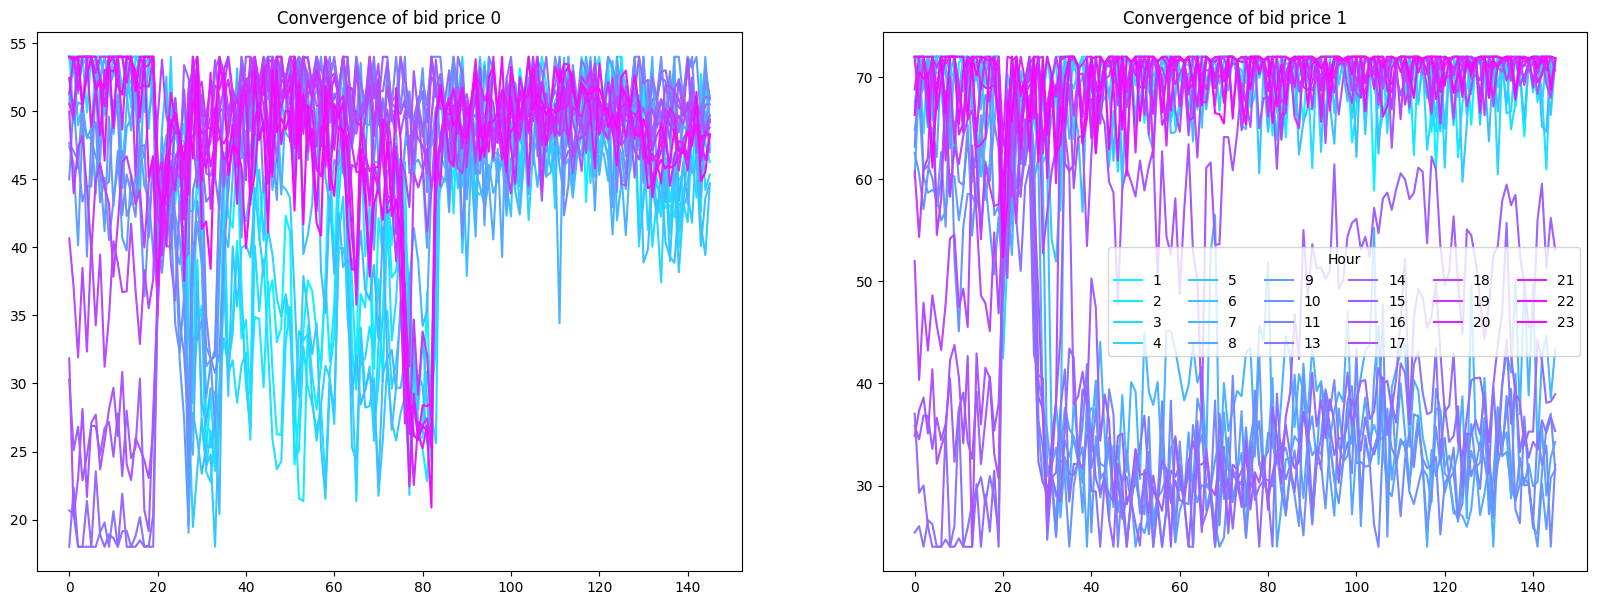

In [136]:
fig, (ax0, ax1) = plt.subplots(1,2, figsize=(20,7))
cols = [(i/24,1-i/24,1) for i in range(24)]

for dt, dt_profit in profit_dfs["operator"].groupby("datetime"):
    ax0.plot((dt_profit["actions_0"].values + 2) * 18, c=cols[dt.hour], label=dt.hour)
    ax1.plot((dt_profit["actions_1"].values + 2)* 24, c=cols[dt.hour], label=dt.hour)

ax0.set_title("Convergence of bid price 0")
ax1.set_title("Convergence of bid price 1")
ax1.legend(title="Hour", ncols=6)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from util_funcs.db_plot import plot_reward_heatmaps
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

for h in range(1,10):
    clear_output()
    plot_h = profit_dfs["operator"][profit_dfs["operator"]["datetime"].dt.hour == h]
    fig_h, axes_h = plot_reward_heatmaps(plot_h, [18, 24], metric="profit", bins=10)
    fig_h.suptitle(f"Hour {h}")
    display(fig_h)
    time.sleep(1)
    


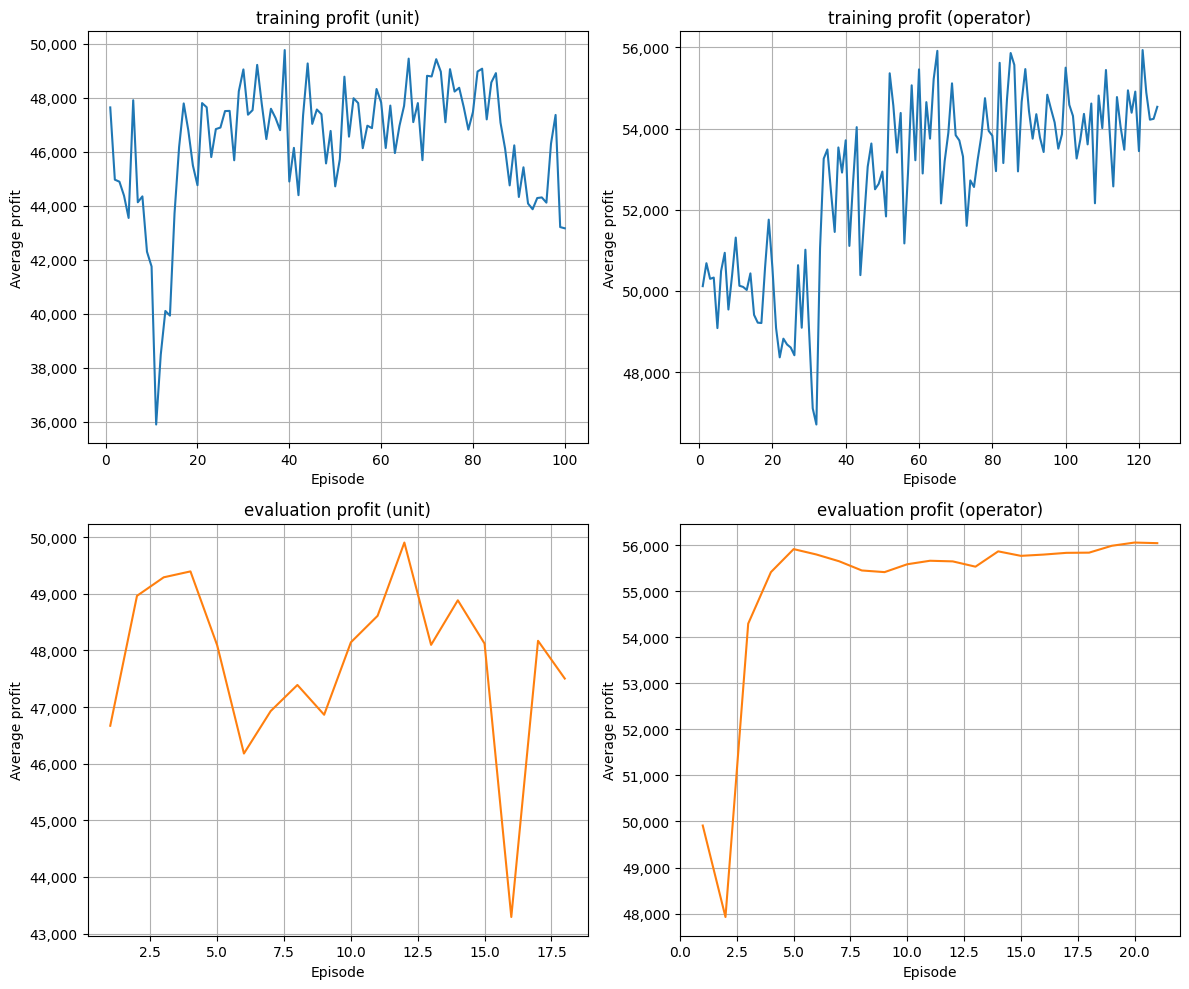

In [140]:
from matplotlib.ticker import FuncFormatter

def comma_formatter(x, pos):
    return f"{x:,.0f}"

# --- Separate plots for training and evaluation ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10),tight_layout=True)
colors = ["tab:blue", "tab:orange"]

for j, bidder in enumerate(profit_dfs):
  for i, mode in enumerate(["training", "evaluation"]):
    
    plot_df = profit_dfs[bidder]
    # training on the left, evaluation on the right
    plot_df = plot_df[plot_df["eval"] == i]
    # average profit over episode and bidders
    # each date of an episode one row, each bidder reward one col
    # compute total profit of RL agents for that episode & date                               
    tot_profit = plot_df.groupby(["datetime", "episode"])["profit"].sum()
    # average of total profit for the same date
    avg_profit = tot_profit.groupby("episode").mean()

    axes[i,j].plot(avg_profit.index, avg_profit.values, color=colors[i])
    axes[i,j].set_title(f"{mode} profit ({bidder})")
    axes[i,j].set_ylabel("Average profit")
    axes[i,j].set_xlabel("Episode")
    axes[i,j].grid(True)
    axes[i,j].yaxis.set_major_formatter(FuncFormatter(comma_formatter))



**Plotting the average profits by date (evaluation only)**

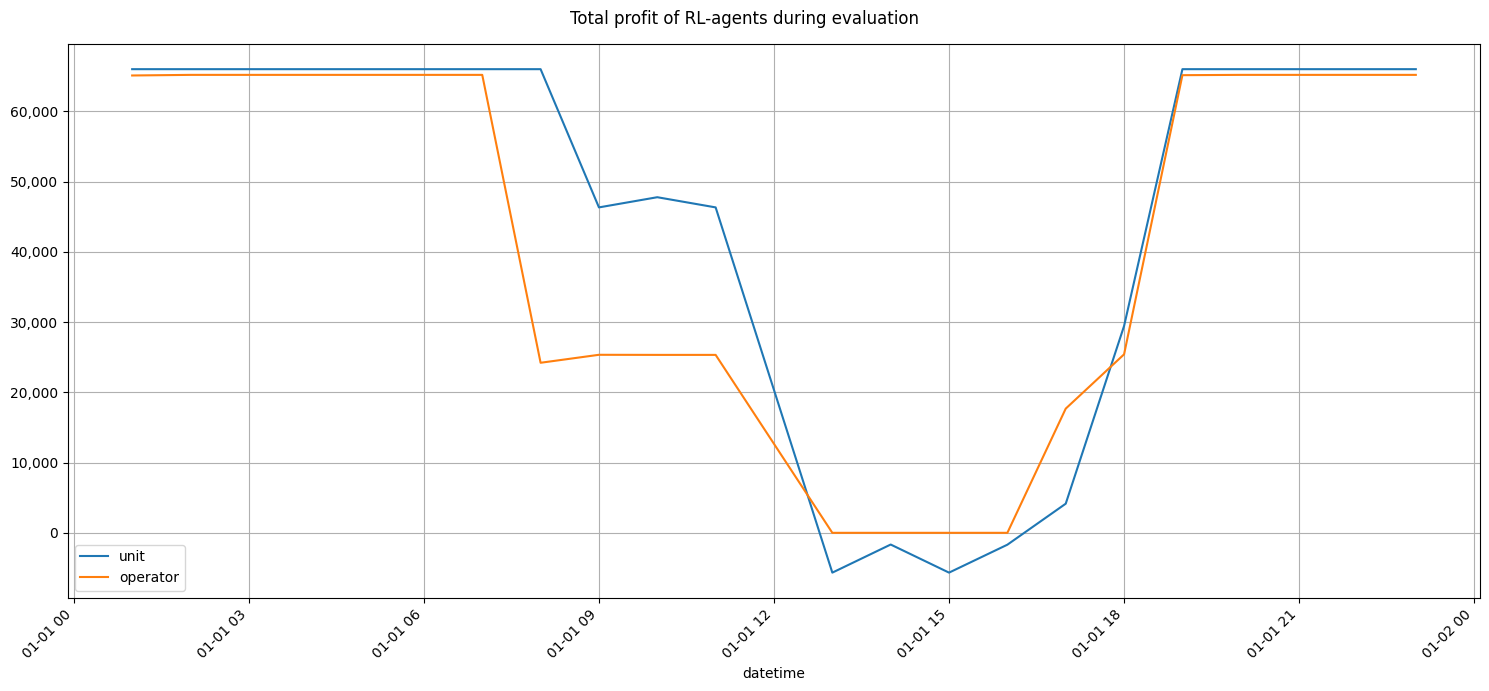

In [25]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(tight_layout=True, figsize=(15,7))

for bidder, profit in profit_dfs.items():
    # select profit during evaluation only 
    eval_profit = profit[profit["eval"] == 1]
    # each date of an episode one row, each bidder reward one col
    eval_bidder = eval_profit.pivot(values="profit", 
                                    columns="unit", 
                                    index=["datetime", "episode"])
    # compute total profit of RL agents for that episode & date                               
    eval_tot = eval_bidder.sum(axis=1)
    # average of total profit for the same date
    profit_by_date = eval_tot.groupby("datetime").mean()
    profit_by_date.plot(ax=ax, label=bidder)

fig.suptitle("Total profit of RL-agents during evaluation")
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(comma_formatter))
ax.legend()
ax.grid(True)


**Compute reward and RSI in final simulation**

In [ ]:
import os, sys
import numpy as np
from IPython.display import Markdown, display

from util_funcs.db_read import *
from market_power.util_funcs.market_power_index import *

%load_ext autoreload
%autoreload 2

names  = "competitive", "unit", "operator" , "best"
examples = "base_mc", "base_un", "base_op", "best"

inputs_path = "inputs"

bids_dfs = {}
running_profit_dfs = {}
dispatch_dfs = {}
rsi_dfs = {}
li_dfs = {}
ms_dfs = {}
gap_dfs = {}


for name, example in zip(names, examples):
    outputs_path = f"outputs/{example}/{example}_base"
    if name == "best":
        df = read_market_orders(example, simulation_id="base_mc_base")
        
    else:
        df = read_market_orders(example)

    bids_dfs[name] = df
    profits = df.groupby(["datetime", "unit_operator"])["profit"].sum().unstack()
    running_profit_dfs[name] = profits["Operator-RL"]    
    dispatch = df.groupby(["datetime", "unit_operator"])["accepted_volume"].sum().unstack()
    dispatch_dfs[name] =dispatch["Operator-RL"]           
    rsi_dfs[name] = residual_supply_index(outputs_path)["Operator-RL"]
    li_dfs[name] = lerner_index(outputs_path)["Operator-RL"]
    ms_dfs[name] = marginal_share(outputs_path)["Operator-RL"]
    gap_dfs[name] = output_gap(outputs_path)["Operator-RL"]

template = (
    "| Model | " + " | ".join(name.title() for name in names) + " |\n"
    "|--------|" + "--------|" * len(names) + "\n"
    "| Total profit (€)  | " + " | ".join(f'{running_profit_dfs[name].sum():,.0f}' for name in names) + " |\n"
    #  "| P-value  | " + " | ".join('-' if name == "competitive" else f'{nw_mean_test(running_profit_dfs[name],running_profit_dfs["competitive"])[-1]:.5f}' for name in names) + " |\n"
    "| Total dispatch (GWh) | " + " | ".join(f'{dispatch_dfs[name].sum():,.0f}' for name in names) + " |\n"
    "| RSI corr             | " + " | ".join(f'{running_profit_dfs[name].corr(rsi_dfs[name]):.2f}' for name in names) + " |\n"
    "| Marginal (% of hours)| " + " | ".join(f'{ms_dfs[name]:.2f}'  for name in names) + " |\n"
    "| Average LI              | " + " | ".join(f'{li_dfs[name].mean():.2f}'  for name in names) + " |\n"
    "| (std)                | " + " | ".join(f'{li_dfs[name].std():.2f}'  for name in names) + " |\n"
    "| Output gap           | " + " | ".join(f'{gap_dfs[name].mean():.2%}'  for name in names) + " |\n"
    "| (std)                | " + " | ".join(f'{gap_dfs[name].std():.2f}'  for name in names) + " |\n"

)

display(Markdown(template)) 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Market orders read.
Market orders read.
Market orders read.
Market orders read.


| Model | Competitive | Unit | Operator | Best |
|--------|--------|--------|--------|--------|
| Total profit (€)  | 954,000 | 529,212 | 1,310,709 | 1,391,999 |
| Total dispatch (GWh) | 39,000 | 18,000 | 30,000 | 32,500 |
| RSI corr             | -0.78 | -0.91 | -0.96 | -0.99 |
| Marginal (% of hours)| 0.25 | 0.21 | 0.67 | 0.83 |
| Average LI              | 0.00 | 0.32 | 0.66 | 0.98 |
| (std)                | 0.00 | 0.24 | 0.01 | 0.07 |
| Output gap           | 0.00% | 0.00% | 12.50% | 10.83% |
| (std)                | 0.00 | 0.00 | 0.13 | 0.10 |


In [20]:
import os, sys
import numpy as np
from IPython.display import Markdown, display

from util_funcs.db_read import *
from util_funcs.market_power_index import *

%load_ext autoreload
%autoreload 2

names  = "competitive", "unit", "operator" , "best"
examples = "base_mc", "base_un", "base_op", "best"

inputs_path = "inputs"

bids_dfs = {}
running_profit_dfs = {}
dispatch_dfs = {}
rsi_dfs = {}
li_dfs = {}
ms_dfs = {}
gap_dfs = {}


for name, example in zip(names, examples):
    outputs_path = f"outputs/{example}/{example}_base"
    if name == "best":
        df = read_market_orders(example, simulation_id="base_mc_base")
        
    else:
        df = read_market_orders(example)

    bids_dfs[name] = df
    profits = df.groupby(["datetime", "unit_operator"])["profit"].sum().unstack()
    running_profit_dfs[name] = profits["Operator-RL"]    
    dispatch = df.groupby(["datetime", "unit_operator"])["accepted_volume"].sum().unstack()
    dispatch_dfs[name] =dispatch["Operator-RL"]           
    rsi_dfs[name] = residual_supply_index(df)["Operator-RL"]
    li_dfs[name] = lerner_index(df)["Operator-RL"]
    ms_dfs[name] = marginal_share(df)["Operator-RL"]
    gap_dfs[name] = output_gap(df)["Operator-RL"]

template = (
    "| Model | " + " | ".join(name.title() for name in names) + " |\n"
    "|--------|" + "--------|" * len(names) + "\n"
    "| Total profit (Mn€)  | " + " | ".join(f'{running_profit_dfs[name].sum() / 10**6:,.4f}' for name in names) + " |\n"
    #  "| P-value  | " + " | ".join('-' if name == "competitive" else f'{nw_mean_test(running_profit_dfs[name],running_profit_dfs["competitive"])[-1]:.5f}' for name in names) + " |\n"
    "| Total dispatch (GWh) | " + " | ".join(f'{dispatch_dfs[name].sum() / 10**6:,.4f}' for name in names) + " |\n"
    "| RSI corr             | " + " | ".join(f'{running_profit_dfs[name].corr(rsi_dfs[name]):.2f}' for name in names) + " |\n"
    "| Marginal (% of hours)| " + " | ".join(f'{ms_dfs[name]:.2f}'  for name in names) + " |\n"
    "| Average LI              | " + " | ".join(f'{li_dfs[name].mean():.2f}'  for name in names) + " |\n"
    "| (std)                | " + " | ".join(f'{li_dfs[name].std():.2f}'  for name in names) + " |\n"
    "| Output gap           | " + " | ".join(f'{gap_dfs[name].mean():.2%}'  for name in names) + " |\n"
    "| (std)                | " + " | ".join(f'{gap_dfs[name].std():.2f}'  for name in names) + " |\n"

)

display(Markdown(template)) 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Market orders read.
Market orders read.
Market orders read.
Market orders read.


| Model | Competitive | Unit | Operator | Best |
|--------|--------|--------|--------|--------|
| Total profit (Mn€)  | 0.9540 | 0.5292 | 1.3107 | 1.3920 |
| Total dispatch (GWh) | 0.0390 | 0.0180 | 0.0300 | 0.0325 |
| RSI corr             | -0.49 | -0.82 | -0.94 | -0.98 |
| Marginal (% of hours)| 0.25 | 0.17 | 0.67 | 0.83 |
| Average LI              | 0.00 | 0.32 | 0.66 | 0.60 |
| (std)                | 0.00 | 0.24 | 0.01 | 0.13 |
| Output gap           | 0.78% | 1.04% | 1.56% | 1.35% |
| (std)                | 0.01 | 0.02 | 0.01 | 0.01 |


**Plotting bids**

In [22]:
bids_dfs["unit"]

,accepted_price,accepted_volume,bid_id,bid_type,end_time,market_id,node,price,simulation,unit_id,volume,unit_operator,max_power,technology,energy_generation_costs,power,marginal_cost,profit
datetime,,,,,,,,,,,,,,,,,,
2019-01-01 02:00:00,54.0,1000.0,pp_1_1,None,2019-01-01 03:00:00.000000,EOM,node0,12.000000,base_un_base,pp_1,1000.0,Operator 1,1000.0,nuclear,12000.0,1000.0,12.0,42000.0
2019-01-01 02:00:00,54.0,1000.0,pp_2_1,None,2019-01-01 03:00:00.000000,EOM,node0,12.000000,base_un_base,pp_2,1000.0,Operator 1,1000.0,nuclear,12000.0,1000.0,12.0,42000.0
2019-01-01 02:00:00,54.0,1000.0,pp_4_1,None,2019-01-01 03:00:00.000000,EOM,node0,24.000000,base_un_base,pp_4,1000.0,Operator 1,1000.0,hard coal,24000.0,1000.0,24.0,30000.0
2019-01-01 02:00:00,54.0,500.0,pp_7_1,None,2019-01-01 03:00:00.000000,EOM,node0,54.000000,base_un_base,pp_7,500.0,Operator 1,500.0,combined cycle gas turbine,27000.0,500.0,54.0,0.0
2019-01-01 02:00:00,54.0,500.0,pp_8_1,None,2019-01-01 03:00:00.000000,EOM,node0,54.000000,base_un_base,pp_8,500.0,Operator 1,500.0,combined cycle gas turbine,27000.0,500.0,54.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-02 00:00:00,54.0,-6000.0,demand_EOM_1,None,2019-01-02 01:00:00.000000,EOM,node0,3000.000000,base_un_base,demand_EOM,-6000.0,None,NaN,None,18000000.0,-6000.0,0.0,-324000.0
2019-01-02 00:00:00,54.0,0.0,pp_7_1,None,2019-01-02 01:00:00.000000,EOM,node0,54.000000,base_un_base,pp_7,500.0,Operator 1,500.0,combined cycle gas turbine,0.0,0.0,0.0,0.0
2019-01-02 00:00:00,54.0,0.0,pp_9_1,None,2019-01-02 01:00:00.000000,EOM,node0,100.000000,base_un_base,pp_9,500.0,Operator 1,500.0,oil,0.0,0.0,0.0,0.0


KeyError: Timestamp('2019-01-01 01:00:00')

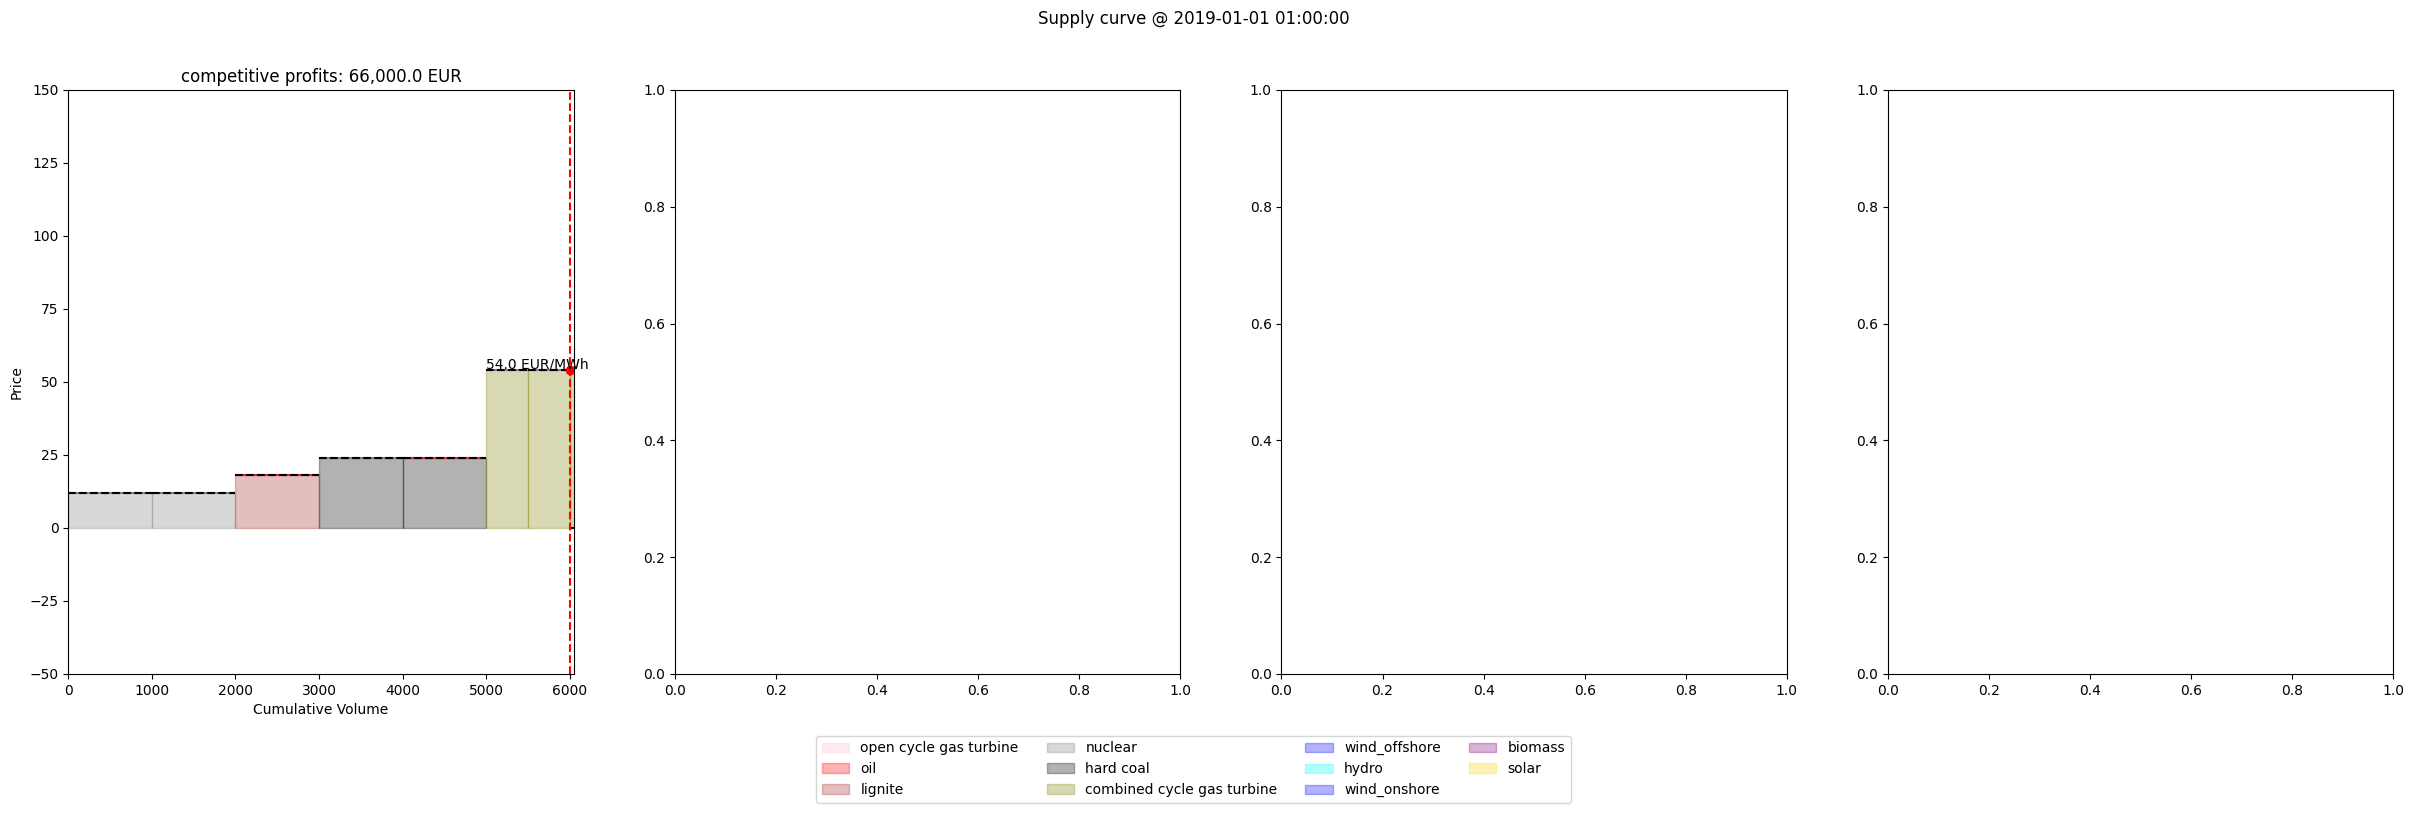

In [21]:
from util_funcs.db_plot import * 
plot_supply_curves(bids_dfs)

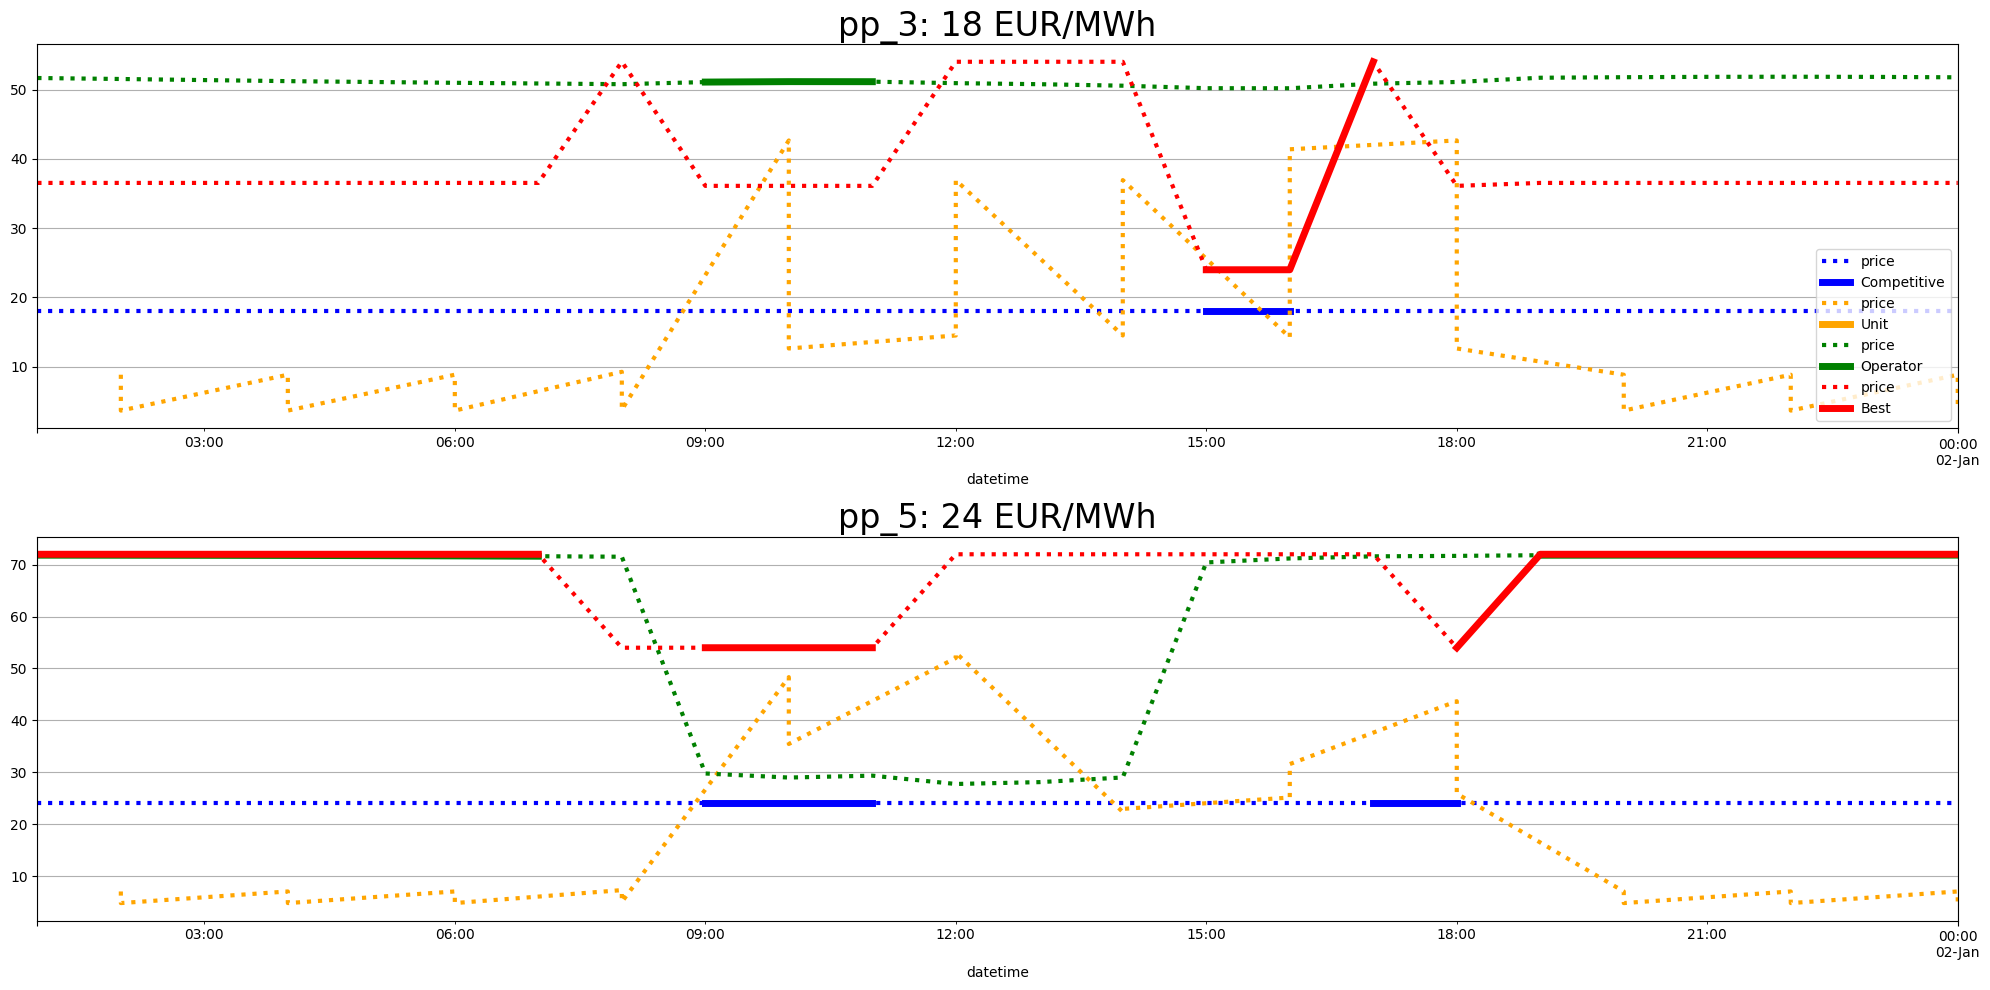

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["axes.grid"] = True
fig, axes = plt.subplots(2, figsize=(20,10), tight_layout=True)
mc = (18, 24, 54)
c = ["b", "orange", "g", "r"]
for j, name in enumerate(bids_dfs):   
    bids = bids_dfs[name]
    op_bids = bids[bids["unit_operator"] == "Operator-RL"]

    for i, (unit_id, unit_bids) in enumerate(op_bids.groupby("unit_id")):
        p = unit_bids["price"]
        p.plot(ax=axes[i], lw=3, ls=":", c=c[j])
        p.where(p==unit_bids["accepted_price"]).plot(ax=axes[i], lw=5, c=c[j], label=name.title())
        
        if j == 0:
            axes[i].set_title(f"{unit_id}: {mc[i]} EUR/MWh", fontsize=24)
    

axes[0].legend()



In [5]:
import seaborn as sns

markups = []

for example, bids in bids_dfs.items():
    if example == "competitive":
        continue
    bids["markup"] = bids["price"] / bids["marginal_cost"]
    bids["Simulation"] = example
    bids = bids[bids["accepted_volume"] > 0 ]
    markups.append(bids)

markups = pd.concat(markups)
sns.histplot(markups.reset_index(), x="markup", hue="Simulation", bins=10, common_norm=False, multiple="dodge", stat="probability")

NameError: name 'bids_dfs' is not defined

This concludes our tutorial. By following these steps, you have successfully created a RL Portfolio Strategy and integrated it into the ASSUME framework.